In [1]:
import json
import os
import random

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import resnet50
from tqdm.auto import tqdm
from sklearn.metrics import f1_score  # criterio de best-checkpoint (F1-macro en validación)
import wandb  # pip install wandb, si no esta ya en el entorno del workstation

/media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

device: cuda


In [3]:
SEED = 42


def seed_everything(seed=SEED):
    """Fija todas las fuentes de aleatoriedad del notebook.

    Cubre la init de la cabeza (linear1/bn1/linear2 en FullModel), el
    shuffle del DataLoader de train y la RandomRotation/RandomHorizontalFlip
    del train_transform (usan el RNG global de torch porque el DataLoader
    corre con num_workers=0). Mismo patrón que scripts/gen_lr_backbone_grid.py
    (exp10-exp19) — mantenerlo consistente si se copia esta celda a nuevos
    notebooks del bloque exp24+.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Determinismo en cuDNN: reproducible a costa de algo de velocidad.
    # Con benchmark=True cuDNN elige algoritmos según el hardware y la
    # misma semilla deja de dar el mismo resultado entre máquinas.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything()
print(f"Semilla fijada: {SEED} (cudnn.deterministic=True, benchmark=False)")

Semilla fijada: 42 (cudnn.deterministic=True, benchmark=False)


In [4]:
EXP_ID = "exp51"
RUN_NAME = "exp51_resnet50_holdoutwarmstart_mammobench_nocmmd_l4l3l2_mlp05_cebalanced_lr1e-4_img256_bs16_split801010"
UNFROZEN_DESC = "layer4 + layer3 + layer2 descongelados (máximo antes del stem/layer1)"
BLOCK = 11  # bloque 11: split 80/10/10 SIN CMMD (manifests/fedmammobench_no_cmmd.csv,
            # generado por scripts/filter_manifest_exclude_cmmd.py) + warm-start desde
            # weights/holdout_best.pt (backbone Y cabeza, no solo backbone como en el
            # resto de la serie -- viene de otro experimento en esta máquina, origen
            # exacto sin identificar) + sin sampler, CE ponderada por clase en su lugar
            # (ver celda de class_weight). Un solo punto de profundidad, no una rejilla.
# Índices de backbone (nn.Sequential) a descongelar — ver freeze cell para el mapa completo.
UNFREEZE_IDX = [7, 6, 5]  # layer4 + layer3 + layer2
HEAD = "mlp"

LR = 1e-4            # cabeza (linear1/bn1/linear2/bn2/linear3)
LR_BACKBONE = 1e-4   # backbone descongelado — igual a LR, consistente con el resto de la serie
DROPOUT = 0.5
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 16
NUM_EPOCHS = 100
PATIENCE = 20
IMAGE_SIZE = 256
ROTATION_DEGREES = 7

PROJECT_ROOT = Path(
    "/media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/"
    "Federal Learning/infraestructura federada/Federal-Learning"
)

DATASET_ROOT = Path(
    "/media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/02-Databases/Mammo-Bench/"
    "c86fb00c-0fb8-4e0e-85a2-4d415f9c1ada_1a9410d8-9769-4064-a064-0160f2fd193d_"
    "DATASET-FILE_Mammo_Bench_zip_20241225112148174/Mammo_Data/Mammo-Bench"
)

# 80/10/10, igual que fedmammobench.csv (bloques 6-8), pero con TODAS las filas de
# CMMD eliminadas de train/val/test -- no solo de test, de las tres. Generado por
# scripts/filter_manifest_exclude_cmmd.py (filtro puro, no re-split: los otros 3
# datasets ya estaban al 80/10/10 dentro de sí mismos, así que quitar CMMD entero deja
# la proporción global intacta sin tocar ningún split de ningún paciente). Efecto
# grande a tener en cuenta: CMMD era ~56.6% de las imágenes y el dataset con más tasa
# de maligno (~49%), así que sin él el train pasa de 34.1% a 14.9% maligno -- un
# desbalance bastante más fuerte que el resto de la serie (ver celda de class_weight).
SPLIT_SCHEME = "80/10/10 (sin CMMD)"
MANIFEST_PATH = PROJECT_ROOT / "manifests" / "fedmammobench_no_cmmd.csv"

# Backbone Y cabeza calientes desde otro experimento en esta máquina (origen exacto
# sin identificar), NO desde RadImageNet-resnet50.pth como el resto de la serie. Trae
# backbone.{0,1,4-7} (misma convención nn.Sequential que RadImageNet-resnet50.pth) +
# fc.{0,1,4,5,8} -- una cabeza Linear/BN/ReLU/Dropout x2 + Linear final que coincide
# EXACTO en forma con linear1/bn1/linear2/bn2/linear3 de FullModel (ver celda de carga
# de pesos, más abajo).
HOLDOUT_WEIGHTS_PATH = PROJECT_ROOT / "weights" / "holdout_best.pt"

# W&B: la API key NUNCA se pega aquí. Se lee de la variable de entorno
# WANDB_API_KEY, o de las credenciales cacheadas en ~/.netrc tras correr
# `wandb login` una vez en este workstation (a diferencia de los
# contenedores Docker del paquete, aqui el notebook SI hereda ese
# ~/.netrc porque corre directo en el host, sin aislar el filesystem).
WANDB_PROJECT = "fedmammobench"
WANDB_ENTITY = None  # None -> entity por defecto de la API key
WANDB_MODE = "online"  # "online" | "offline" | "disabled"
WANDB_TAGS = ["notebook", "centralized", "holdout-warmstart", "mammobench", "no-cmmd", "l4l3l2", "img256", "class-weighted-ce", "split801010"]

RUN_DIR = PROJECT_ROOT / "runs" / RUN_NAME
PLOTS_DIR = RUN_DIR / "plots"
# Métricas/gráficas globales (todo el test set) van en PLOTS_DIR y metrics.json.
# El desglose por source_dataset va aparte, en su propia carpeta, para no
# mezclar los dos niveles de granularidad.
PER_DATASET_DIR = RUN_DIR / "per_dataset"
RUN_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
PER_DATASET_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = RUN_DIR / "best_model.pth"
LAST_MODEL_PATH = RUN_DIR / "last_model.pth"

print(f"RUN_DIR: {RUN_DIR}")


RUN_DIR: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp51_resnet50_holdoutwarmstart_mammobench_nocmmd_l4l3l2_mlp05_cebalanced_lr1e-4_img256_bs16_split801010


In [5]:
# W&B init. `WandbWriter` (src/fedmammobench/utils/wandb_utils.py) hace este
# mismo degradado en el paquete; aqui se replica a mano porque el notebook no
# importa fedmammobench. Nunca debe bloquear ni pedir la key por input():
# si no hay credenciales, cae a modo offline (o se desactiva del todo).
os.environ.setdefault("WANDB_SILENT", "true")

wandb_run = None
if WANDB_MODE != "disabled":
    mode = WANDB_MODE
    has_creds = bool(os.environ.get("WANDB_API_KEY", "").strip()) or bool(wandb.api.api_key)
    if mode == "online" and not has_creds:
        print(
            "No hay WANDB_API_KEY ni credenciales cacheadas (~/.netrc); "
            "corriendo wandb en modo offline. Sincroniza despues con "
            "`wandb sync` sobre la carpeta wandb/ de este run."
        )
        mode = "offline"

    try:
        wandb_run = wandb.init(
            project=WANDB_PROJECT,
            entity=WANDB_ENTITY,
            name=RUN_NAME,
            group=EXP_ID,
            tags=WANDB_TAGS,
            mode=mode,
            dir=str(RUN_DIR),
            config={
                "exp_id": EXP_ID,
                "seed": SEED,
                "block": BLOCK,
                "manifest": MANIFEST_PATH.name,
                "split_scheme": SPLIT_SCHEME,
                "excluded_dataset": "cmmd",
                "weights_source": "holdout_best.pt (backbone + cabeza)",
                "unfrozen": UNFROZEN_DESC,
                "unfreeze_idx": UNFREEZE_IDX,
                "head": HEAD,
                "loss": "CrossEntropyLoss",
                "class_weight": "inverse_freq (calculado tras cargar train; valor exacto en metrics.json)",
                "sampler": None,
                "lr": LR,
                "lr_backbone": LR_BACKBONE if HEAD == "mlp" else None,
                "dropout": DROPOUT if HEAD == "mlp" else None,
                "weight_decay": WEIGHT_DECAY,
                "batch_size": BATCH_SIZE,
                "num_epochs": NUM_EPOCHS,
                "patience": PATIENCE,
                "image_size": IMAGE_SIZE,
                "rotation_degrees": ROTATION_DEGREES,
            },
        )
        print(f"W&B run ({mode}): {getattr(wandb_run, 'url', None) or RUN_DIR / 'wandb'}")
    except Exception as exc:
        print(f"wandb.init() fallo ({exc!r}); se continua sin W&B.")
        wandb_run = None
else:
    print("W&B desactivado (WANDB_MODE = 'disabled').")


W&B run (online): https://wandb.ai/j-mast8924-instituci-n-universitaria-itm/fedmammobench/runs/9k7xazwq


In [6]:
SPLIT_COL = "split"
LABEL_COL = "classification"
PATH_COL = "preprocessed_image_path"

TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT = "train", "val", "test"


class CSVDataset(Dataset):
    def __init__(self, csv_file=None, split=None, root_dir="", transform=None, label_to_idx=None,
                 dataframe=None):
        if dataframe is not None:
            # Filas ya resueltas por el llamador (p.ej. un subset de test_processed.data
            # filtrado por source_dataset) — se usan tal cual, sin leer ni filtrar por split.
            self.data = dataframe.reset_index(drop=True)
        else:
            self.data = pd.read_csv(csv_file)

            missing = {SPLIT_COL, LABEL_COL, PATH_COL} - set(self.data.columns)
            if missing:
                raise KeyError(
                    f"El manifest {csv_file} no tiene la(s) columna(s) {sorted(missing)}. "
                    f"Columnas disponibles: {list(self.data.columns)}"
                )

            available = sorted(self.data[SPLIT_COL].dropna().unique())
            if split not in available:
                raise ValueError(
                    f"split={split!r} no existe en la columna {SPLIT_COL!r}. "
                    f"Valores disponibles: {available}"
                )

            self.data = self.data[self.data[SPLIT_COL] == split].reset_index(drop=True)

        if len(self.data) == 0:
            source = f"split {split!r}" if dataframe is None else "el dataframe recibido"
            raise ValueError(f"El dataset quedó vacío ({source}).")

        self.root_dir = Path(root_dir)
        self.transform = transform

        if label_to_idx is None:
            labels = sorted(self.data[LABEL_COL].unique())
            self.label_to_idx = {label: i for i, label in enumerate(labels)}
        else:
            self.label_to_idx = label_to_idx

        unknown = set(self.data[LABEL_COL].unique()) - set(self.label_to_idx)
        if unknown:
            raise ValueError(
                f"Hay etiquetas {sorted(unknown)} ausentes en label_to_idx={self.label_to_idx}."
            )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        img_path = Path(self.root_dir) / Path(row[PATH_COL])
        image = Image.open(img_path).convert("RGB")

        label = self.label_to_idx[row[LABEL_COL]]

        if self.transform:
            image = self.transform(image)

        return image, label

In [7]:
_manifest = pd.read_csv(MANIFEST_PATH)

_required = {SPLIT_COL, LABEL_COL, PATH_COL}
assert _required <= set(_manifest.columns), (
    f"Faltan columnas en el manifest: {sorted(_required - set(_manifest.columns))}"
)

_splits = sorted(_manifest[SPLIT_COL].dropna().unique())
assert set(_splits) >= {TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT}, (
    f"El manifest solo tiene splits {_splits}; se esperaban "
    f"{[TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT]}"
)

print(f"Filas totales: {len(_manifest)}\n")
print(pd.crosstab(_manifest[SPLIT_COL], _manifest[LABEL_COL], margins=True))

if "source_dataset" in _manifest.columns:
    print()
    print(pd.crosstab(_manifest["source_dataset"], _manifest[SPLIT_COL], margins=True))

Filas totales: 3619

classification  Benign  Malignant   All
split                                  
test               315         47   362
train             2463        432  2895
val                313         49   362
All               3091        528  3619

split           test  train  val   All
source_dataset                        
cdd-cesm         100    803  100  1003
inbreast          40    328   42   410
kau-bcmd         222   1764  220  2206
All              362   2895  362  3619


In [8]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(ROTATION_DEGREES),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [9]:
train_processed = CSVDataset(
    csv_file=MANIFEST_PATH, split=TRAIN_SPLIT, root_dir=DATASET_ROOT,
    transform=train_transform,
)
validation_processed = CSVDataset(
    csv_file=MANIFEST_PATH, split=VAL_SPLIT, root_dir=DATASET_ROOT,
    transform=val_transform, label_to_idx=train_processed.label_to_idx,
)
test_processed = CSVDataset(
    csv_file=MANIFEST_PATH, split=TEST_SPLIT, root_dir=DATASET_ROOT,
    transform=val_transform, label_to_idx=train_processed.label_to_idx,
)

print(f"label_to_idx: {train_processed.label_to_idx}")
print(f"train: {len(train_processed)} | val: {len(validation_processed)} | test: {len(test_processed)}")

label_to_idx: {'Benign': 0, 'Malignant': 1}
train: 2895 | val: 362 | test: 362


In [10]:
# Sin WeightedRandomSampler en este bloque (a diferencia de exp37-46): con CMMD
# fuera, ya no hay 4 bases con P(maligno|dataset) muy dispar (0.046..0.489) --
# solo quedan 3 (cdd-cesm/inbreast/kau-bcmd) y el desbalance dominante vuelve a
# ser de CLASE dentro del conjunto ya filtrado (train 14.9% maligno, ver celda
# de class_weight más abajo). Se decidió compensarlo con
# CrossEntropyLoss(weight=...) en vez de re-muestrear -- mismo criterio que
# exp33/34 (bloque 7).
_loader_generator = torch.Generator()
_loader_generator.manual_seed(SEED)


def _seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


# drop_last=True: la cabeza usa BatchNorm1d, que revienta si el último batch de
# la época queda con 1 sola muestra.
train = DataLoader(
    train_processed, batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
    worker_init_fn=_seed_worker, generator=_loader_generator,
)
validation = DataLoader(validation_processed, batch_size=BATCH_SIZE, shuffle=False)
test = DataLoader(test_processed, batch_size=BATCH_SIZE, shuffle=False)

print(f"train: {len(train_processed)} img -> {len(train)} batches/época "
      f"(batch_size={BATCH_SIZE}, drop_last=True, shuffle=True)")
print(f"val:   {len(validation_processed)} img -> {len(validation)} batches/época")
print(f"test:  {len(test_processed)} img -> {len(test)} batches/época")


train: 2895 img -> 180 batches/época (batch_size=16, drop_last=True, shuffle=True)
val:   362 img -> 23 batches/época
test:  362 img -> 23 batches/época


In [11]:
class Classifier(nn.Module):
    def __init__(self, num_class):
        super().__init__()
        self.linear = nn.Linear(2048, num_class)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.linear(x)


class Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        base_model = resnet50(weights=None)
        encoder_layers = list(base_model.children())
        self.backbone = nn.Sequential(*encoder_layers[:9])

    def forward(self, x):
        return self.backbone(x)

In [12]:
def load_holdout_backbone(weights_path, device="cpu"):
    """Carga SOLO el backbone de weights/holdout_best.pt en un resnet50 nuevo.

    holdout_best.pt guarda su backbone con la MISMA convención nn.Sequential que
    RadImageNet-resnet50.pth ("backbone.0.weight" en vez de "conv1.weight") --
    mismo remap que load_radimagenet_backbone (bloques 6-10), reescrito aquí en
    vez de reusar esa función porque este checkpoint también trae los tensores
    fc.* de la cabeza, que hay que extraer aparte (ver load_holdout_head_state).
    """
    model = resnet50(weights=None)
    checkpoint = torch.load(weights_path, map_location=device)
    state_dict = checkpoint["state_dict"] if isinstance(checkpoint, dict) and "state_dict" in checkpoint else checkpoint
    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

    backbone_remap = {
        "backbone.0.": "conv1.",
        "backbone.1.": "bn1.",
        "backbone.4.": "layer1.",
        "backbone.5.": "layer2.",
        "backbone.6.": "layer3.",
        "backbone.7.": "layer4.",
    }
    remapped = {}
    for k, v in state_dict.items():
        new_k = k
        for old_prefix, new_prefix in backbone_remap.items():
            if k.startswith(old_prefix):
                new_k = new_prefix + k[len(old_prefix):]
                break
        remapped[new_k] = v

    backbone_state = {
        k: v for k, v in remapped.items()
        if k.startswith(("conv1", "bn1", "relu", "maxpool", "layer1", "layer2", "layer3", "layer4", "avgpool"))
    }
    if len(backbone_state) == 0:
        raise RuntimeError(
            "0 tensores de backbone matchearon tras el remap — revisar el formato "
            "de holdout_best.pt antes de continuar."
        )

    missing, unexpected = model.load_state_dict(backbone_state, strict=False)
    print(f"Loaded {len(backbone_state)} backbone tensors from holdout_best.pt.")
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)

    # Trunca a conv1..avgpool para que la salida (batch, 2048, 1, 1) encaje
    # con linear1(2048, ...) de la cabeza.
    encoder_layers = list(model.children())
    return nn.Sequential(*encoder_layers[:9])


def load_holdout_head_state(weights_path, device="cpu"):
    """Extrae los tensores fc.* de holdout_best.pt, remapeados a los nombres que
    usa FullModel (linear1/bn1/linear2/bn2/linear3).

    fc.{0,1,4,5,8} tienen EXACTO la misma forma que esa cabeza (Linear
    2048->512, BatchNorm1d, Linear 512->512, BatchNorm1d, Linear 512->2) --
    fc.{2,3,6,7} son ReLU/Dropout, sin parámetros, y no aparecen en el
    checkpoint, igual que backbone.{2,3,8} (relu/maxpool/avgpool) arriba.
    """
    checkpoint = torch.load(weights_path, map_location=device)
    state_dict = checkpoint["state_dict"] if isinstance(checkpoint, dict) and "state_dict" in checkpoint else checkpoint
    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

    head_remap = {
        "fc.0.": "linear1.",
        "fc.1.": "bn1.",
        "fc.4.": "linear2.",
        "fc.5.": "bn2.",
        "fc.8.": "linear3.",
    }
    head_state = {}
    for k, v in state_dict.items():
        for old_prefix, new_prefix in head_remap.items():
            if k.startswith(old_prefix):
                head_state[new_prefix + k[len(old_prefix):]] = v
                break

    if len(head_state) == 0:
        raise RuntimeError("0 tensores de cabeza (fc.*) encontrados en holdout_best.pt.")
    return head_state


backbone = load_holdout_backbone(HOLDOUT_WEIGHTS_PATH, device=device).to(device)


Loaded 318 backbone tensors from holdout_best.pt.
Missing keys: ['fc.weight', 'fc.bias']
Unexpected keys: []


In [13]:
# Índices de backbone (nn.Sequential, ver backbone_remap en load_radimagenet_backbone):
# 0=conv1, 1=bn1, 4=layer1, 5=layer2, 6=layer3, 7=layer4 (2=relu/3=maxpool/8=avgpool
# no tienen parámetros). UNFREEZE_IDX se fija en la celda de parámetros — esta celda
# es la misma para las 5 profundidades del bloque, solo cambia UNFREEZE_IDX.
for param in backbone.parameters():
    param.requires_grad = False
for idx in UNFREEZE_IDX:
    for param in backbone[idx].parameters():
        param.requires_grad = True

trainable = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
total = sum(p.numel() for p in backbone.parameters())
pct = 100 * trainable / total
print(f"[{EXP_ID}] Backbone trainable params: {trainable:,} / {total:,} ({pct:.2f}%)")

[exp51] Backbone trainable params: 23,282,688 / 23,508,032 (99.04%)


In [14]:
train_loss_history = []
val_loss_history = []
val_f1_history = []


def freeze_bn_running_stats(module):
    # requires_grad=False congela gamma/beta pero NO running_mean/running_var,
    # que se siguen actualizando en cada forward en modo train(). eval() las fija.
    for m in module.modules():
        if isinstance(m, nn.BatchNorm2d) and not m.weight.requires_grad:
            m.eval()


def train_model(model, criterion, optimizer, num_epochs=NUM_EPOCHS, sheduler=None,
                patience=PATIENCE):
    # Best-checkpoint y early stopping se rigen por F1-macro en validación, no
    # por la loss: con clases desbalanceadas la loss puede seguir bajando
    # (el modelo se vuelve más "seguro") mientras el F1 de la clase minoritaria
    # empeora, así que es un mejor criterio de "mejor modelo" que la loss sola.
    best_val_f1 = -1.0
    train_loss_history.clear()
    val_loss_history.clear()
    val_f1_history.clear()
    counter = 0
    best_epoch = 0

    epoch_bar = tqdm(range(num_epochs), desc="Epochs", unit="epoch")
    for e in epoch_bar:
        train_loss = 0.0
        model.train()
        freeze_bn_running_stats(model)
        train_bar = tqdm(train, desc=f"  train {e+1}/{num_epochs}", unit="batch", leave=False)
        for data, labels in train_bar:
            # CrossEntropyLoss espera índices de clase (long), no floats.
            data, labels = data.to(device, dtype=torch.float), labels.to(device, dtype=torch.long)

            optimizer.zero_grad()
            target = model(data)
            loss = criterion(target, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        valid_loss = 0.0
        val_preds_epoch, val_labels_epoch = [], []
        model.eval()
        val_bar = tqdm(validation, desc=f"  val   {e+1}/{num_epochs}", unit="batch", leave=False)
        with torch.no_grad():
            for data, labels in val_bar:
                data, labels = data.to(device, dtype=torch.float), labels.to(device, dtype=torch.long)

                target = model(data)
                loss = criterion(target, labels)
                valid_loss += loss.item()
                val_bar.set_postfix(loss=f"{loss.item():.4f}")

                val_preds_epoch.extend(torch.argmax(target, dim=1).cpu().numpy())
                val_labels_epoch.extend(labels.cpu().numpy())

        avg_train_loss = train_loss / len(train)
        avg_valid_loss = valid_loss / len(validation)
        avg_valid_f1 = f1_score(val_labels_epoch, val_preds_epoch, average="macro")
        train_loss_history.append(avg_train_loss)
        val_loss_history.append(avg_valid_loss)
        val_f1_history.append(avg_valid_f1)
        epoch_bar.set_postfix(
            train_loss=f"{avg_train_loss:.4f}", val_loss=f"{avg_valid_loss:.4f}", val_f1=f"{avg_valid_f1:.4f}",
        )

        if wandb_run is not None:
            wandb_run.log(
                {
                    "train/loss": avg_train_loss,
                    "val/loss": avg_valid_loss,
                    "val/f1_macro": avg_valid_f1,
                },
                step=e + 1,
            )

        print(
            f"Epoch {e+1} \t\t Training Loss: {avg_train_loss} \t\t "
            f"Validation Loss: {avg_valid_loss} \t\t Validation F1-macro: {avg_valid_f1:.6f}"
        )

        torch.save(model.state_dict(), LAST_MODEL_PATH)

        if avg_valid_f1 > best_val_f1:
            print(f"Validation F1-macro increased({best_val_f1:.6f}--->{avg_valid_f1:.6f}) \t Saving The Model")
            best_val_f1 = avg_valid_f1
            best_epoch = e + 1
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            counter = 0
        else:
            counter += 1
            print(f"EarlyStopping counter: {counter} out of {patience}")

        if counter >= patience:
            print(f"Early stopping triggered en la época {e+1}. Mejor época: {best_epoch}.")
            break

        if sheduler is not None:
            sheduler.step()

    print(f"\nMejor época: {best_epoch} (val F1-macro {best_val_f1:.6f}) -> {BEST_MODEL_PATH}")
    print(f"Última época: {len(train_loss_history)} -> {LAST_MODEL_PATH}")
    return model

In [15]:
class FullModel(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.linear1  = nn.Linear(2048, 512)
        self.bn1      = nn.BatchNorm1d(512)
        self.act1     = nn.ReLU(inplace=True)
        self.dropout1 = nn.Dropout(p=DROPOUT)

        self.linear2  = nn.Linear(512, 512)
        self.bn2      = nn.BatchNorm1d(512)
        self.act2     = nn.ReLU(inplace=True)
        self.dropout2 = nn.Dropout(p=DROPOUT)

        # 2 logits (benigno/maligno) para CrossEntropyLoss, en vez de 1 logit
        # + sigmoid (BCEWithLogitsLoss).
        self.linear3  = nn.Linear(512, 2)

    def forward(self, x):

        x = self.backbone(x)
        x = x.view(x.size(0), -1)

        x = self.linear1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.dropout1(x)

        x = self.linear2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.dropout2(x)

        x = self.linear3(x)
        return x  # logits [batch, 2] crudos; CrossEntropyLoss aplica softmax internamente


seed_everything()  # reproducibilidad de lo que sí queda aleatorio (dropout, etc.)
model = FullModel(backbone).to(device)

# A diferencia de TODO el resto de la serie (exp01-50, que siempre reinicializan
# la cabeza con normal_(0, 0.01) sin importar de dónde viene el backbone), aquí
# la cabeza TAMBIÉN se carga desde holdout_best.pt -- backbone y cabeza
# calientes, no solo backbone. Rompe la comparabilidad directa contra el resto
# de la serie en este eje (la cabeza no arranca de init aleatoria), pero es
# justo lo que se pidió para este experimento.
head_state = load_holdout_head_state(HOLDOUT_WEIGHTS_PATH, device=device)
missing, unexpected = model.load_state_dict(head_state, strict=False)
_head_missing = [k for k in missing if not k.startswith("backbone.")]
_head_unexpected = [k for k in unexpected if not k.startswith("backbone.")]
print(f"Loaded {len(head_state)} head tensors from holdout_best.pt.")
print("Missing head keys:", _head_missing)
print("Unexpected head keys:", _head_unexpected)
assert not _head_missing and not _head_unexpected, "la cabeza de holdout_best.pt no calzó 1 a 1 con FullModel"


Loaded 16 head tensors from holdout_best.pt.
Missing head keys: []
Unexpected head keys: []


In [16]:
# class_weight balanceado: sin CMMD el train queda ~85/15 Benign/Malignant (vs.
# ~66/34 con CMMD -- CMMD era el dataset con más tasa de maligno de los 4, ver
# celda de parámetros). No hay sampler en este bloque (se decidió compensar el
# desbalance de CLASE con la loss, no con el muestreo -- ver celda de
# DataLoaders), así que sin esto el gradiente estaría dominado por Benign.
# Mismo criterio que exp33/34 (bloque 7) y que compute_class_weights del
# paquete (src/fedmammobench/training/losses.py): peso inverso a la frecuencia
# de cada clase, normalizado a media 1. Se calcula sobre train_processed (no
# val/test) porque es la distribución que el modelo ve batch a batch.
train_labels_idx = train_processed.data[LABEL_COL].map(train_processed.label_to_idx).to_numpy()
class_counts = np.bincount(train_labels_idx, minlength=2).astype(np.float64)
class_weights_np = class_counts.sum() / (class_counts * 2)
class_weights_np = class_weights_np / class_weights_np.mean()
class_weights = torch.as_tensor(class_weights_np, dtype=torch.float32, device=device)
label_order = sorted(train_processed.label_to_idx, key=train_processed.label_to_idx.get)
print(f"class_counts (train, orden {label_order}): {class_counts.tolist()}")
print(f"class_weights (orden {label_order}): {class_weights.tolist()}")

criterion = nn.CrossEntropyLoss(weight=class_weights)

# Grupos de parámetros dinámicos -- igual que exp42-50: recoge lo que haya
# quedado con requires_grad=True en el backbone, y TODO lo que no sea backbone
# para la cabeza (por nombre, no listando capas a mano -- ese fue justo el bug
# de exp35-41 que dejaba bn2/linear3 sin entrenar nunca, ver CLAUDE.md).
backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
head_params = [p for name, p in model.named_parameters() if not name.startswith("backbone.")]

param_groups = [{"params": head_params, "lr": LR, "name": "head"}]
if backbone_params:
    param_groups.append({"params": backbone_params, "lr": LR_BACKBONE, "name": "backbone"})

optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
sheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

trainable_params = [p for p in model.parameters() if p.requires_grad]
print(f"Optimizer: AdamW(lr_head={LR}, lr_backbone={LR_BACKBONE if backbone_params else None}, weight_decay={WEIGHT_DECAY})")
for g in optimizer.param_groups:
    n = sum(p.numel() for p in g["params"])
    print(f"  grupo {g['name']:9} lr={g['lr']:<8} params={n:,}")
print(f"Parámetros entrenables: {sum(p.numel() for p in trainable_params):,}")


class_counts (train, orden ['Benign', 'Malignant']): [2463.0, 432.0]
class_weights (orden ['Benign', 'Malignant']): [0.29844558238983154, 1.7015544176101685]
Optimizer: AdamW(lr_head=0.0001, lr_backbone=0.0001, weight_decay=0.0001)
  grupo head      lr=0.0001   params=1,314,818
  grupo backbone  lr=0.0001   params=23,282,688
Parámetros entrenables: 24,597,506


In [17]:
model = train_model(model, criterion, optimizer, num_epochs=NUM_EPOCHS,
                    sheduler=sheduler, patience=PATIENCE)

Epochs:   0%|          | 0/100 [00:00<?, ?epoch/s]

  train 1/100:   0%|          | 0/180 [00:00<?, ?batch/s]

  val   1/100:   0%|          | 0/23 [00:00<?, ?batch/s]

Epoch 1 		 Training Loss: 0.7076345970233281 		 Validation Loss: 0.48191225010415784 		 Validation F1-macro: 0.656850


Validation F1-macro increased(-1.000000--->0.656850) 	 Saving The Model


...

EarlyStopping counter: 19 out of 20


  train 54/100:   0%|          | 0/180 [00:00<?, ?batch/s]

  val   54/100:   0%|          | 0/23 [00:00<?, ?batch/s]

Epoch 54 		 Training Loss: 0.022725952476968007 		 Validation Loss: 1.2472751227806325 		 Validation F1-macro: 0.629990


EarlyStopping counter: 20 out of 20
Early stopping triggered en la época 54. Mejor época: 34.

Mejor época: 34 (val F1-macro 0.690542) -> /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp51_resnet50_holdoutwarmstart_mammobench_nocmmd_l4l3l2_mlp05_cebalanced_lr1e-4_img256_bs16_split801010/best_model.pth
Última época: 54 -> /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp51_resnet50_holdoutwarmstart_mammobench_nocmmd_l4l3l2_mlp05_cebalanced_lr1e-4_img256_bs16_split801010/last_model.pth


Epoch   1 	 Training Loss: 0.707635 	 Validation Loss: 0.481912 	 Validation F1-macro: 0.656850
Epoch   2 	 Training Loss: 0.592351 	 Validation Loss: 0.476650 	 Validation F1-macro: 0.616541
Epoch   3 	 Training Loss: 0.555727 	 Validation Loss: 0.487013 	 Validation F1-macro: 0.620204
Epoch   4 	 Training Loss: 0.515199 	 Validation Loss: 0.485548 	 Validation F1-macro: 0.612612
Epoch   5 	 Training Loss: 0.499018 	 Validation Loss: 0.420624 	 Validation F1-macro: 0.656087
Epoch   6 	 Training Loss: 0.462567 	 Validation Loss: 0.445418 	 Validation F1-macro: 0.641365
Epoch   7 	 Training Loss: 0.421931 	 Validation Loss: 0.476149 	 Validation F1-macro: 0.616247
Epoch   8 	 Training Loss: 0.405788 	 Validation Loss: 0.455098 	 Validation F1-macro: 0.634998
Epoch   9 	 Training Loss: 0.382845 	 Validation Loss: 0.453584 	 Validation F1-macro: 0.626487
Epoch  10 	 Training Loss: 0.358144 	 Validation Loss: 0.505061 	 Validation F1-macro: 0.662393
Epoch  11 	 Training Loss: 0.318281 	 Va

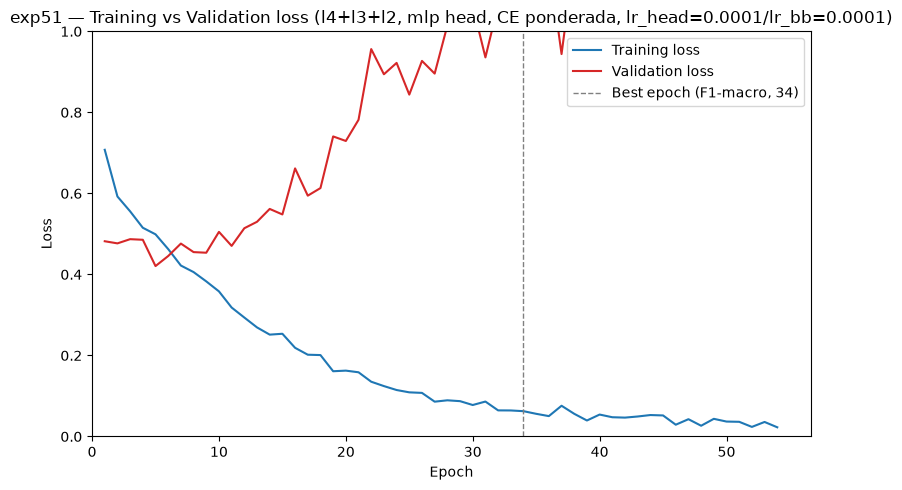

In [18]:
import matplotlib.pyplot as plt

best_epoch = int(np.argmax(val_f1_history)) + 1

for epoch, (t_loss, v_loss, v_f1) in enumerate(zip(train_loss_history, val_loss_history, val_f1_history), start=1):
    marker = "  <-- best (max val F1-macro)" if epoch == best_epoch else ""
    print(
        f"Epoch {epoch:3d} \t Training Loss: {t_loss:.6f} \t Validation Loss: {v_loss:.6f} "
        f"\t Validation F1-macro: {v_f1:.6f}{marker}"
    )

loss_history_path = RUN_DIR / "loss_history.csv"
pd.DataFrame({
    "epoch": range(1, len(train_loss_history) + 1),
    "train_loss": train_loss_history,
    "val_loss": val_loss_history,
    "val_f1_macro": val_f1_history,
}).to_csv(loss_history_path, index=False)
print(f"\nHistorial guardado en: {loss_history_path}")

fig, ax = plt.subplots(figsize=(8, 5))
epochs_range = range(1, len(train_loss_history) + 1)
ax.plot(epochs_range, train_loss_history, label="Training loss", color="#1f77b4")
ax.plot(epochs_range, val_loss_history, label="Validation loss", color="#d62728")
ax.axvline(best_epoch, linestyle="--", color="gray", lw=1, label=f"Best epoch (F1-macro, {best_epoch})")
ax.set_xlim(left=0)
ax.set_ylim(0, 1)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"{EXP_ID} — Training vs Validation loss (l4+l3+l2, mlp head, CE ponderada, lr_head={LR}/lr_bb={LR_BACKBONE})")
ax.legend()
fig.tight_layout()

loss_curve_path = PLOTS_DIR / "loss_curve.png"
fig.savefig(loss_curve_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {loss_curve_path}")
plt.show()


In [19]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)


def evaluate_model(model, checkpoint_path, dataloader, device=device, desc="eval"):
    """Carga `checkpoint_path` en `model` y lo evalúa sobre `dataloader`.

    El caller arma el DataLoader (el `test` de todo el split, o uno nuevo sobre el
    subset de un solo source_dataset — ver celda de abajo) y elige con qué checkpoint
    evaluar; esta función solo hace inferencia + métricas, sin construir datasets ni
    decidir qué filas evaluar, así que sirve igual para el desglose global o por dataset.
    """
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    labels, preds, probs = [], [], []
    with torch.no_grad():
        for data, lbl in tqdm(dataloader, desc=desc, unit="batch", leave=False):
            data = data.to(device, dtype=torch.float)
            logits = model(data)
            p = torch.softmax(logits, dim=1)
            pred = torch.argmax(logits, dim=1)

            labels.extend(lbl.numpy())
            preds.extend(pred.cpu().numpy())
            # p[:, 1] = P(clase 1), score que roc_auc_score espera en binario.
            probs.extend(p[:, 1].cpu().numpy())

    n = len(labels)
    result = {"n_samples": n, "labels": labels, "preds": preds, "probs": probs}
    if n == 0 or len(set(labels)) < 2:
        # AUC/precision/recall/F1 no están bien definidos con una sola clase presente (o 0 muestras).
        result["warning"] = "menos de 2 clases en este subset; AUC/precision/recall/F1 se omiten"
        result["accuracy"] = float(accuracy_score(labels, preds)) if n else None
        result["auc"] = result["precision"] = result["recall"] = result["f1"] = None
    else:
        result["accuracy"] = float(accuracy_score(labels, preds))
        result["auc"] = float(roc_auc_score(labels, probs))
        result["precision"] = float(precision_score(labels, preds, pos_label=1, zero_division=0))
        result["recall"] = float(recall_score(labels, preds, pos_label=1, zero_division=0))
        result["f1"] = float(f1_score(labels, preds, pos_label=1, zero_division=0))
    result["confusion_matrix"] = confusion_matrix(labels, preds, labels=[0, 1]).tolist()
    return result


def save_predictions_csv(manifest_df, result, out_path):
    """Guarda `manifest_df` (las mismas filas que se evaluaron) con 3 columnas nuevas:
    y_true (índice de clase real), y_pred (índice de clase predicho) y y_prob
    (P(clase 1) — el mismo score que roc_auc_score y la curva ROC usan).

    y_true/y_pred/y_prob se asignan por posición, no por índice de fila, así que
    `manifest_df` debe conservar el mismo orden de fila que vio el DataLoader
    (shuffle=False, igual que en toda esta sección) — CSVDataset(dataframe=...) no
    reordena filas, solo resetea el índice, así que esto vale tanto para
    test_processed.data (global) como para un subset filtrado por source_dataset.
    """
    out_df = manifest_df.copy()
    out_df["y_true"] = result["labels"]
    out_df["y_pred"] = result["preds"]
    out_df["y_prob"] = result["probs"]
    out_df.to_csv(out_path, index=False)
    print(f"Predicciones guardadas en: {out_path}")
    return out_path


idx_to_label = {v: k for k, v in train_processed.label_to_idx.items()}
global_result = evaluate_model(model, BEST_MODEL_PATH, test, desc="Test (global)")
all_labels, all_preds, all_probs = global_result["labels"], global_result["preds"], global_result["probs"]
test_acc, test_auc = global_result["accuracy"], global_result["auc"]

save_predictions_csv(test_processed.data, global_result, RUN_DIR / "predictions.csv")

print(f"label_to_idx: {train_processed.label_to_idx}  (clase positiva para AUC = {idx_to_label[1]!r})")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC AUC:  {test_auc:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=[idx_to_label[0], idx_to_label[1]]))

Test (global):   0%|          | 0/23 [00:00<?, ?batch/s]

Predicciones guardadas en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp51_resnet50_holdoutwarmstart_mammobench_nocmmd_l4l3l2_mlp05_cebalanced_lr1e-4_img256_bs16_split801010/predictions.csv
label_to_idx: {'Benign': 0, 'Malignant': 1}  (clase positiva para AUC = 'Malignant')
Test accuracy: 0.8398
Test ROC AUC:  0.8464

              precision    recall  f1-score   support

      Benign       0.93      0.88      0.91       315
   Malignant       0.41      0.55      0.47        47

    accuracy                           0.84       362
   macro avg       0.67      0.72      0.69       362
weighted avg       0.86      0.84      0.85       362



Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp51_resnet50_holdoutwarmstart_mammobench_nocmmd_l4l3l2_mlp05_cebalanced_lr1e-4_img256_bs16_split801010/plots/test_confusion_matrix.png


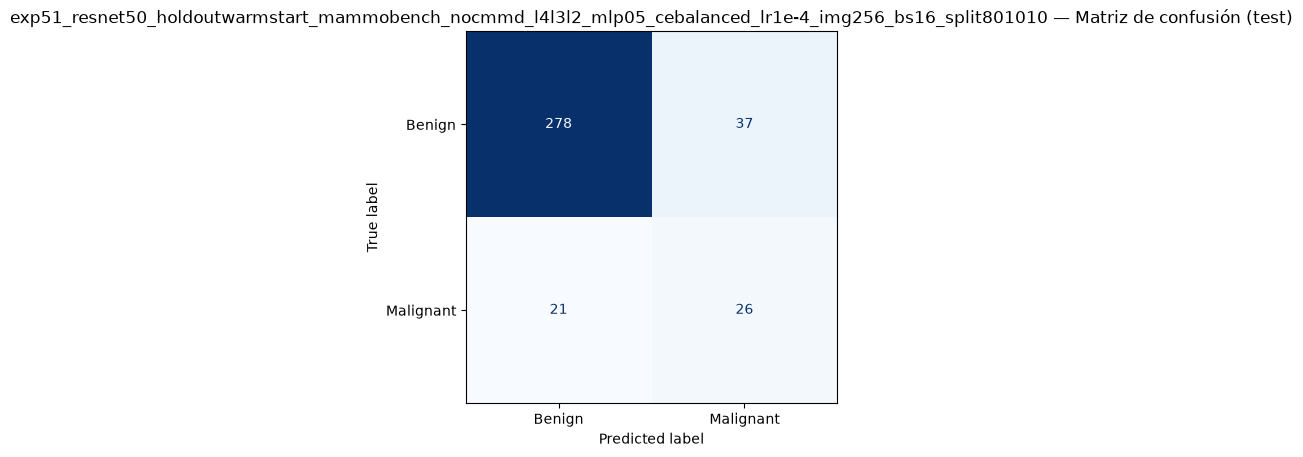

Accuracy  : 0.8398
ROC AUC   : 0.8464
Precision : 0.4127
Recall    : 0.5532
F1-score  : 0.4727


Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp51_resnet50_holdoutwarmstart_mammobench_nocmmd_l4l3l2_mlp05_cebalanced_lr1e-4_img256_bs16_split801010/plots/test_roc_curve.png


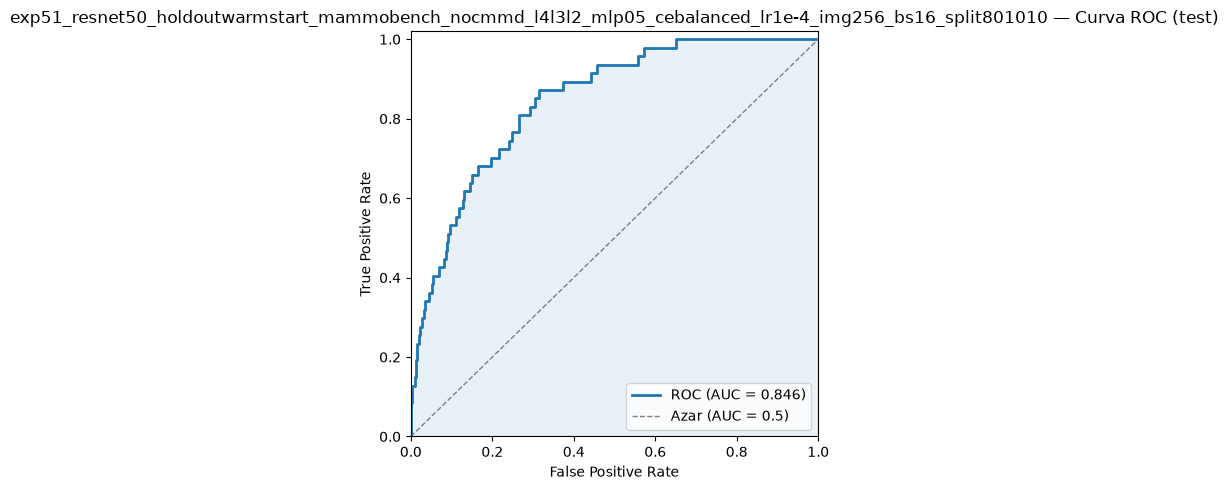

Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp51_resnet50_holdoutwarmstart_mammobench_nocmmd_l4l3l2_mlp05_cebalanced_lr1e-4_img256_bs16_split801010/plots/test_metrics_bar.png


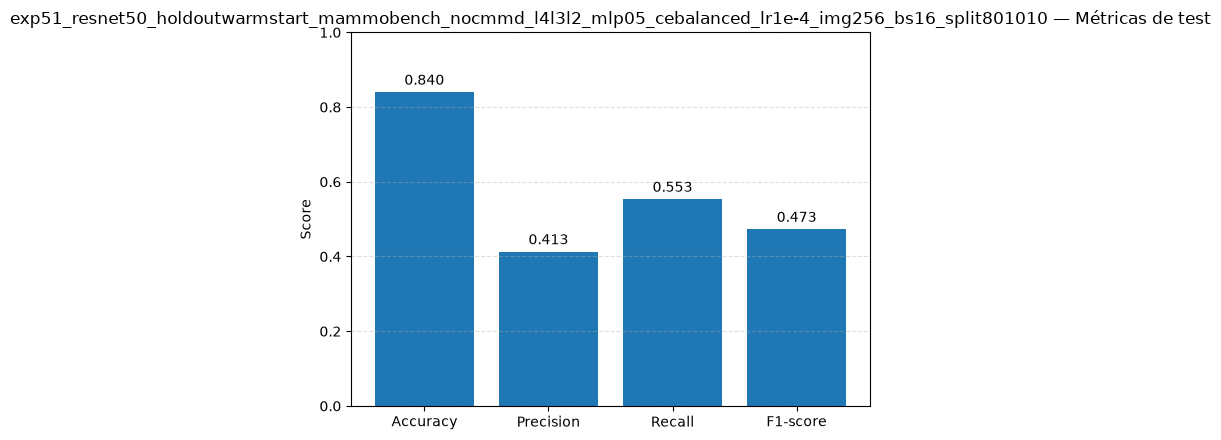

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_curve

test_precision = precision_score(all_labels, all_preds, pos_label=1)
test_recall = recall_score(all_labels, all_preds, pos_label=1)
test_f1 = f1_score(all_labels, all_preds, pos_label=1)
cm = confusion_matrix(all_labels, all_preds)

class_names = [idx_to_label[0], idx_to_label[1]]

fig_cm, ax_cm = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax_cm, cmap="Blues", colorbar=False, values_format="d")
ax_cm.set_title(f"{RUN_NAME} — Matriz de confusión (test)")
fig_cm.tight_layout()

cm_path = PLOTS_DIR / "test_confusion_matrix.png"
fig_cm.savefig(cm_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {cm_path}")
plt.show()

metrics = {
    "Accuracy": test_acc,
    "ROC AUC": test_auc,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1-score": test_f1,
}
for name, value in metrics.items():
    print(f"{name:10s}: {value:.4f}")

if wandb_run is not None:
    wandb_run.log({f"test/{k.lower().replace(' ', '_')}": v for k, v in metrics.items()})
    wandb_run.summary["best_epoch"] = best_epoch
    wandb_run.summary["best_val_loss"] = min(val_loss_history)
    wandb_run.summary["best_val_f1_macro"] = max(val_f1_history)

# ROC AUC es el area bajo la curva ROC: se grafica la curva real, no un punto suelto.
fpr, tpr, _ = roc_curve(all_labels, all_probs)

fig_roc, ax_roc = plt.subplots(figsize=(5, 5))
ax_roc.plot(fpr, tpr, color="#1f77b4", lw=2, label=f"ROC (AUC = {test_auc:.3f})")
ax_roc.fill_between(fpr, tpr, alpha=0.1, color="#1f77b4")
ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1, label="Azar (AUC = 0.5)")
ax_roc.set_xlim(0, 1)
ax_roc.set_ylim(0, 1.02)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title(f"{RUN_NAME} — Curva ROC (test)")
ax_roc.legend(loc="lower right")
fig_roc.tight_layout()

roc_path = PLOTS_DIR / "test_roc_curve.png"
fig_roc.savefig(roc_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {roc_path}")
plt.show()

# Accuracy/Precision/Recall/F1 son escalares puntuales en el mismo rango [0, 1]: se
# comparan mejor juntos en un solo grafico de barras que en 4 graficos de un punto.
bar_metrics = {k: v for k, v in metrics.items() if k != "ROC AUC"}

fig_bar, ax_bar = plt.subplots(figsize=(6, 4.5))
bars = ax_bar.bar(bar_metrics.keys(), bar_metrics.values(), color="#1f77b4")
ax_bar.set_ylim(0, 1)
ax_bar.set_ylabel("Score")
ax_bar.set_title(f"{RUN_NAME} — Métricas de test")
ax_bar.grid(True, axis="y", linestyle="--", alpha=0.4)
ax_bar.bar_label(bars, fmt="%.3f", padding=3)
fig_bar.tight_layout()

bar_path = PLOTS_DIR / "test_metrics_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {bar_path}")
plt.show()

if wandb_run is not None:
    wandb_run.log({
        "test/confusion_matrix": wandb.Image(str(cm_path)),
        "test/roc_curve": wandb.Image(str(roc_path)),
        "test/metrics_bar": wandb.Image(str(bar_path)),
    })
# wandb_run.finish() se movió al final de la sección per-dataset (más abajo),
# para poder seguir logueando a este mismo run mientras se calcula el desglose.

In [21]:
summary = {
    "experiment": EXP_ID,
    "block": BLOCK,
    "run_name": RUN_NAME,
    "unfrozen": UNFROZEN_DESC,
    "unfreeze_idx": UNFREEZE_IDX,
    "seed": SEED,
    "manifest": MANIFEST_PATH.name,
    "split_scheme": SPLIT_SCHEME,
    "excluded_dataset": "cmmd",
    "weights_source": "holdout_best.pt (backbone + cabeza)",
    "hyperparams": {
        "head": HEAD,
        "dropout": DROPOUT if HEAD == "mlp" else None,
        "lr": LR,
        "lr_backbone": LR_BACKBONE,
        "weight_decay": WEIGHT_DECAY,
        "batch_size": BATCH_SIZE,
        "num_epochs": NUM_EPOCHS,
        "patience": PATIENCE,
        "image_size": IMAGE_SIZE,
        "optimizer": "AdamW",
        "loss": "CrossEntropyLoss",
        "class_weight": class_weights.tolist(),
        "sampler": None,
        "scheduler": "CosineAnnealingLR",
        "augmentation": f"RandomRotation({ROTATION_DEGREES}) + RandomHorizontalFlip(p=0.5)",
        "seed": SEED,
        "best_checkpoint_metric": "val_f1_macro",
    },
    "epochs_run": len(train_loss_history),
    "best_epoch": best_epoch,
    "best_val_loss": float(min(val_loss_history)),
    "best_val_f1_macro": float(max(val_f1_history)),
    "final_train_loss": float(train_loss_history[-1]),
    "final_val_loss": float(val_loss_history[-1]),
    "test": {
        "accuracy": float(test_acc),
        "auc": float(test_auc),
        "precision": float(test_precision),
        "recall": float(test_recall),
        "f1": float(test_f1),
        "confusion_matrix": cm.tolist(),
        "class_names": class_names,
    },
    # Desglose por source_dataset (cdd-cesm/inbreast/kau-bcmd -- sin cmmd):
    # archivo aparte, calculado en las celdas de abajo, no inline aquí — ver
    # PER_DATASET_DIR.
    "per_dataset_metrics_path": str(PER_DATASET_DIR / "metrics_per_dataset.json"),
    "checkpoints": {
        "best": str(BEST_MODEL_PATH),
        "last": str(LAST_MODEL_PATH),
    },
}

metrics_path = RUN_DIR / "metrics.json"
metrics_path.write_text(json.dumps(summary, indent=2))
print(f"Resumen guardado en: {metrics_path}")
print(json.dumps(summary["test"], indent=2))


Resumen guardado en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp51_resnet50_holdoutwarmstart_mammobench_nocmmd_l4l3l2_mlp05_cebalanced_lr1e-4_img256_bs16_split801010/metrics.json
{
  "accuracy": 0.8397790055248618,
  "auc": 0.846403242147923,
  "precision": 0.4126984126984127,
  "recall": 0.5531914893617021,
  "f1": 0.4727272727272727,
  "confusion_matrix": [
    [
      278,
      37
    ],
    [
      21,
      26
    ]
  ],
  "class_names": [
    "Benign",
    "Malignant"
  ]
}


In [22]:
per_dataset_metrics = {}
for name in sorted(test_processed.data["source_dataset"].unique()):
    subset_df = test_processed.data[test_processed.data["source_dataset"] == name]
    subset_dataset = CSVDataset(
        dataframe=subset_df, root_dir=DATASET_ROOT, transform=val_transform,
        label_to_idx=train_processed.label_to_idx,
    )
    subset_loader = DataLoader(subset_dataset, batch_size=BATCH_SIZE, shuffle=False)

    result = evaluate_model(model, BEST_MODEL_PATH, subset_loader, desc=f"Test ({name})")
    save_predictions_csv(subset_df, result, PER_DATASET_DIR / f"predictions_{name}.csv")
    for key in ("labels", "preds", "probs"):
        result.pop(key, None)  # ya están volcadas al csv de predicciones; no hacen falta en el json de métricas
    per_dataset_metrics[name] = result

for name, m in per_dataset_metrics.items():
    print(f"--- {name} (n={m['n_samples']}) ---")
    for k, v in m.items():
        if k not in ("confusion_matrix", "n_samples"):
            print(f"  {k:10s}: {v}")
    print()

if wandb_run is not None:
    for name, m in per_dataset_metrics.items():
        wandb_run.log({
            f"test_per_dataset/{name}/{k}": v
            for k, v in m.items()
            if isinstance(v, (int, float))
        })

per_dataset_metrics_path = PER_DATASET_DIR / "metrics_per_dataset.json"
per_dataset_metrics_path.write_text(json.dumps(per_dataset_metrics, indent=2))
print(f"Métricas por dataset guardadas en: {per_dataset_metrics_path}")

Test (cdd-cesm):   0%|          | 0/7 [00:00<?, ?batch/s]

Predicciones guardadas en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp51_resnet50_holdoutwarmstart_mammobench_nocmmd_l4l3l2_mlp05_cebalanced_lr1e-4_img256_bs16_split801010/per_dataset/predictions_cdd-cesm.csv


Test (inbreast):   0%|          | 0/3 [00:00<?, ?batch/s]

Predicciones guardadas en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp51_resnet50_holdoutwarmstart_mammobench_nocmmd_l4l3l2_mlp05_cebalanced_lr1e-4_img256_bs16_split801010/per_dataset/predictions_inbreast.csv


Test (kau-bcmd):   0%|          | 0/14 [00:00<?, ?batch/s]

Predicciones guardadas en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp51_resnet50_holdoutwarmstart_mammobench_nocmmd_l4l3l2_mlp05_cebalanced_lr1e-4_img256_bs16_split801010/per_dataset/predictions_kau-bcmd.csv
--- cdd-cesm (n=100) ---
  accuracy  : 0.72
  auc       : 0.8168249660786975
  precision : 0.5609756097560976
  recall    : 0.696969696969697
  f1        : 0.6216216216216216

--- inbreast (n=40) ---
  accuracy  : 0.55
  auc       : 0.390625
  precision : 0.08333333333333333
  recall    : 0.125
  f1        : 0.1

--- kau-bcmd (n=222) ---
  accuracy  : 0.9459459459459459
  auc       : 0.7430555555555556
  precision : 0.2
  recall    : 0.3333333333333333
  f1        : 0.25

Métricas por dataset guardadas en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp51_resnet50_holdoutwarmstart_mammobench_nocmmd_l

Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp51_resnet50_holdoutwarmstart_mammobench_nocmmd_l4l3l2_mlp05_cebalanced_lr1e-4_img256_bs16_split801010/per_dataset/test_metrics_per_dataset.png


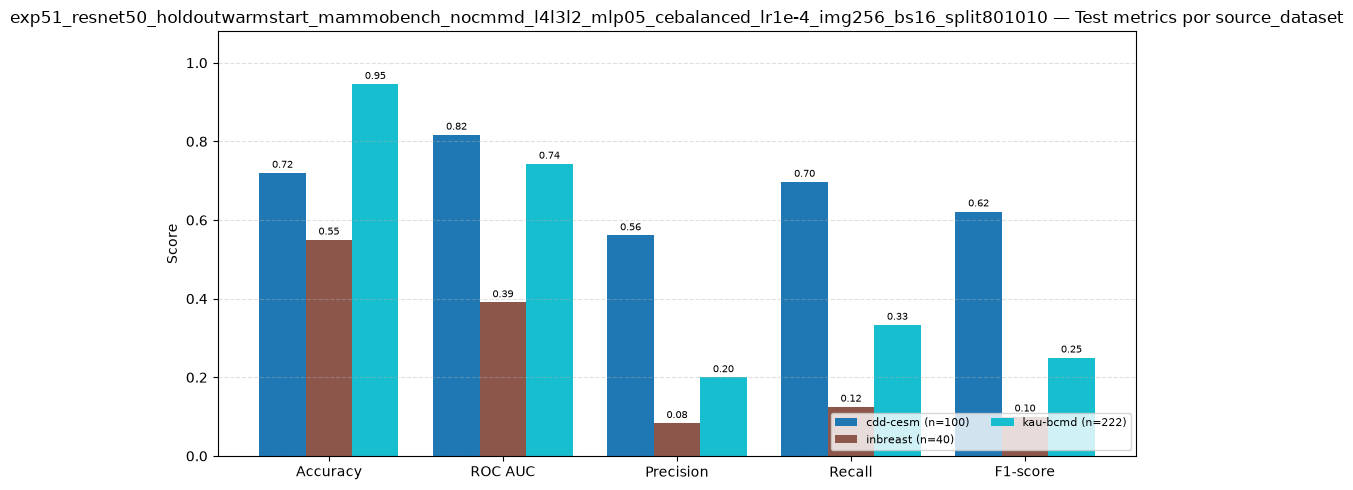

Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp51_resnet50_holdoutwarmstart_mammobench_nocmmd_l4l3l2_mlp05_cebalanced_lr1e-4_img256_bs16_split801010/per_dataset/test_confusion_matrix_per_dataset.png


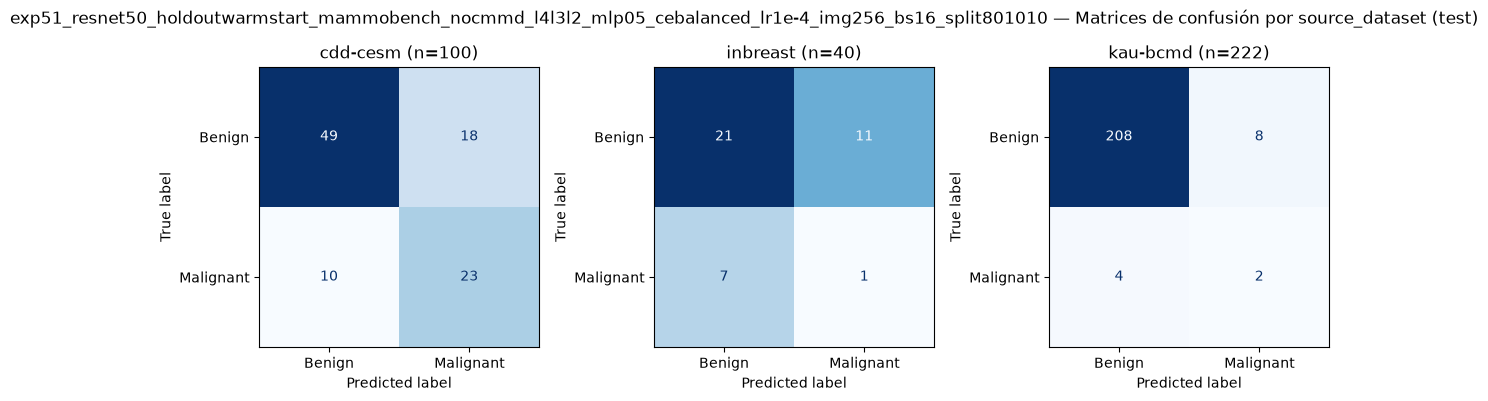

In [23]:
dataset_names = list(per_dataset_metrics.keys())
metric_keys = ["accuracy", "auc", "precision", "recall", "f1"]
metric_labels = ["Accuracy", "ROC AUC", "Precision", "Recall", "F1-score"]

# Barras agrupadas: un grupo por métrica, una barra por dataset — las 5 métricas
# viven en [0, 1], así que se leen mejor juntas que en 5 gráficos sueltos.
fig_bar, ax_bar = plt.subplots(figsize=(10, 5))
x = np.arange(len(metric_keys))
width = 0.8 / len(dataset_names)
colors = plt.cm.tab10(np.linspace(0, 1, len(dataset_names)))

for i, name in enumerate(dataset_names):
    values = [per_dataset_metrics[name][k] or 0.0 for k in metric_keys]
    offset = (i - (len(dataset_names) - 1) / 2) * width
    bars = ax_bar.bar(
        x + offset, values, width,
        label=f"{name} (n={per_dataset_metrics[name]['n_samples']})", color=colors[i],
    )
    ax_bar.bar_label(bars, fmt="%.2f", padding=2, fontsize=7)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metric_labels)
ax_bar.set_ylim(0, 1.08)
ax_bar.set_ylabel("Score")
ax_bar.set_title(f"{RUN_NAME} — Test metrics por source_dataset")
ax_bar.legend(loc="lower right", fontsize=8, ncol=2)
ax_bar.grid(axis="y", linestyle="--", alpha=0.4)
fig_bar.tight_layout()

per_dataset_bar_path = PER_DATASET_DIR / "test_metrics_per_dataset.png"
fig_bar.savefig(per_dataset_bar_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {per_dataset_bar_path}")
plt.show()

# Una matriz de confusión por dataset, en una sola grilla para comparar de un vistazo.
n_ds = len(dataset_names)
fig_cm2, axes_cm2 = plt.subplots(1, n_ds, figsize=(4 * n_ds, 4))
if n_ds == 1:
    axes_cm2 = [axes_cm2]
for ax_cm2, name in zip(axes_cm2, dataset_names):
    cm_ds = np.array(per_dataset_metrics[name]["confusion_matrix"])
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_ds, display_labels=class_names)
    disp2.plot(ax=ax_cm2, cmap="Blues", colorbar=False, values_format="d")
    ax_cm2.set_title(f"{name} (n={per_dataset_metrics[name]['n_samples']})")
fig_cm2.suptitle(f"{RUN_NAME} — Matrices de confusión por source_dataset (test)")
fig_cm2.tight_layout()

per_dataset_cm_path = PER_DATASET_DIR / "test_confusion_matrix_per_dataset.png"
fig_cm2.savefig(per_dataset_cm_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {per_dataset_cm_path}")
plt.show()

if wandb_run is not None:
    wandb_run.log({
        "test_per_dataset/metrics_bar": wandb.Image(str(per_dataset_bar_path)),
        "test_per_dataset/confusion_matrices": wandb.Image(str(per_dataset_cm_path)),
    })
    wandb_run.finish()